### test

In [ ]:
class SwarmState(TypedDict):
    messages: list[any]
    user_query: str
    plan: list[str]
    query_db: any
    relevant_docs: list[dict]


In [5]:
from langgraph.prebuilt import create_react_agent

In [8]:
from tavily import TavilyClient
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
response = tavily_client.search("Who is Leo Messi?")

In [9]:
response

{'query': 'Who is Leo Messi?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Lionel_Messi',
   'title': 'Lionel Messi - Wikipedia',
   'content': "An Argentine international, Messi is the national team's all-time leading goalscorer and most-capped player. Several years after his senior debut in 2005, he",
   'score': 0.86358756,
   'raw_content': None},
  {'url': 'https://www.biography.com/athletes/lionel-messi',
   'title': 'Lionel Messi: Biography, Soccer Player, Inter Miami CF, Athlete',
   'content': 'Lionel Messi, a forward for Inter Miami CF, is one of the world’s greatest soccer players and helped the Argentina national team win its third FIFA World Cup in 2022. Messi, now playing for Inter Miami CF of the MLS, helped his home country win soccer’s biggest event for the first time since 1986, scoring two goals in the final and leading Argentina to a 4-2 win over Kylian Mbappé and France on penalties. Lionel Messi

In [10]:
def search_internet(query: str) -> str:
    """
    Searches the internet for the given query.
    Arguments:
        query: The query to search for.
    Returns:
        A dicitonary containing the search results.

    """

    response = tavily_client.search(query)
    return response

def sum(a: int, b: int) -> int:
    """
    Calculates the sum of two integers.
    Arguments:
        a: The first integer.
        b: The second integer.
    Returns:
        The sum of the two integers.
    """
    return a + b

In [13]:
def get_weather(city: str) -> str:
    """Get weather for a given city."""
    return f"It's always sunny in {city}!"

agent = create_react_agent(
    model=llm,
    tools=[get_weather],
    prompt="You are a helpful assistant"
)

# Run the agent
agent.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf"}]}
)

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='f8dd3e83-eb6a-4cfd-b003-6e351b485e43'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for the weather in SF. I need to figure out which function to use. The available tool is get_weather, which requires a city parameter. SF is a common abbreviation for San Francisco. So I should call get_weather with the city set to San Francisco. Let me make sure there's no other possible interpretation, but SF is widely known as San Francisco. Alright, I'll proceed with that.\n", 'tool_calls': [{'id': 'myq0vhaa5', 'function': {'arguments': '{"city":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 158, 'total_tokens': 269, 'completion_time': 0.218438009, 'prompt_time': 0.006307211, 'queue_time': 0.213958486, 'total_time': 0.22474522}, 'model_name': 'qwen/

### imports

In [1]:
!pip install -q langchain-groq langgraph pymupdf langchain_community langchain_chroma "unstructured[pdf]"
!apt install poppler-utils tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 5.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter
from google.colab import userdata
import os
from uuid import uuid4
from copy import deepcopy

from unstructured.documents.elements import NarrativeText, Title, Image, Table
import fitz
import re
from unstructured.partition.pdf import partition_pdf
from pypdf import PdfWriter, PdfReader


os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_summariser = ChatGroq(model="llama-3.1-8b-instant")
llm_image_summariser = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")


from langchain.vectorstores import Chroma
from langchain.storage import InMemoryStore
from langchain.schema.document import Document
from langchain.retrievers.multi_vector import MultiVectorRetriever
from langchain_community.embeddings import HuggingFaceEmbeddings

### docstore code


In [3]:
def get_summary(text):
    messages = [SystemMessage("""
    Your job is to summarize the given raw text. Chunks of raw text are given to you and you have to analyze properly what all is contained in them.
    Pay special attention to table captions, image captions and formulas and include them in your summaries.
    You can skip the factual numeric details but you must tell what all is contained in the given chunk of raw text.

    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(f"Here is the raw text: {text}"))
    res = llm_summariser.invoke(messages)

    return res.content

def get_image_summary(image_data):
    messages = [SystemMessage("""
    Your job is to summarize the given image.
    If the image is graph, extract relevant details like graph title, axis labels, maximum values etc.
    If the image is a diagram or illustration extract important components and make proper analysis in them.
    Include keywords in your summary that will help map the summary easily to the image
    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(content=[
        {
            "type": "image_url",
            "image_url": {"url": f"data:image/jpeg;base64,{image_data}"},
        }
    ]))
    res = llm_image_summariser.invoke(messages)

    return res.content

def get_table_summary(table_data):
    messages = [SystemMessage("""
    Your job is to summarize the given table. The table is in HTML format. Describe the table properly, include keywords that help in telling what all data is contained in the table.
    Make sure to include the names of column headings or row headings as necessary. Properly analyze the table and return a dense yet concise summary.
    IMPORTANT: Only output the summary and no boilerplate text like "Here's your summary"
    """)]
    messages.append(HumanMessage(f"Here is the table in HTML format: {table_data}"))
    res = llm_summariser.invoke(messages)

    return res.content

In [4]:
class Docstore():
    def __init__(self, pdf_path):
        self.pdf_path = pdf_path


    def get_doc_hierarchy(self):

        def find_toc_pages(doc, search_limit=20):
            toc_pages = []
            for i in range(min(len(doc), search_limit)):
                page = doc[i]
                text = page.get_text("text", sort=True).lower()
                if "contents" in text or "table of contents" in text:
                    toc_pages.append(i)
            return toc_pages

        def toc_raw_to_hierarchy(toc_raw):
            messages = [SystemMessage("""
                You are a document hierarchy generator. Your task is to generate a python dictionary.
                You are given the raw text on the table of contents page of a document.
                analyze it properly and structure it into a neat json object.
                The document hierarchy is only needed till depth level 2. the schema of the json object is as follows
                {
                    "section_name": str
                    "section_children": list[str]
                }
                You must follow this schema.
                YOur output should be json object and it will be evaluated as it is so do not give boilerplate text or backticks
                """)]
            messages.append(HumanMessage("here is the raw text on the table of contents page of the document"))
            messages.append(HumanMessage(toc_raw))

            res = llm.with_structured_output(method="json_mode").invoke(messages)
            return res

        def toc_to_hierarchy(toc):
            hierarchy = []
            for i in range(len(toc)):
                if toc[i][0] == 1:
                    new_section = {
                        "section_name": toc[i][1],
                        "section_children": []
                    }
                    new_section_children = []
                    for j in range(i+1, len(toc)):
                        if toc[j][0] == 2:
                            new_section_children.append(toc[j][1])
                        elif toc[j][0] == 1:
                            break
                    new_section["section_children"] = new_section_children
                    hierarchy.append(new_section)
            return hierarchy

        doc = fitz.open(self.pdf_path)
        toc = doc.get_toc()
        toc_pages = find_toc_pages(doc)
        if toc:
            return toc_to_hierarchy(toc), toc_pages


        if toc_pages:
            toc_raw = ""
            for i in toc_pages:
                toc_raw += doc[i].get_text("text")
            return toc_raw_to_hierarchy(toc_raw), toc_pages

        return None

    def create_headings_store(self):

        self.low_res_elements = partition_pdf(
            filename="report.pdf",
            strategy="fast"
        )
        self.doc_hierarchy, self.toc_pages = self.get_doc_hierarchy()

        doc_hierarchy = deepcopy(self.doc_hierarchy)
        current_section_idx = 0
        current_section_chunks = []

        if self.toc_pages:
            last_toc_page = self.toc_pages[-1]
            split_idx = next(
                (i for i, x in enumerate(elements) if x.metadata.page_number == last_toc_page + 2),
                None
            )
            elements = elements[split_idx:]

        next_section_name = (
            doc_hierarchy[current_section_idx + 1]["section_name"]
            if current_section_idx + 1 < len(doc_hierarchy)
            else None
        )

        for e in self.low_res_elements:
            if next_section_name and isinstance(e, Title) and next_section_name in e.text:
                doc_hierarchy[current_section_idx]["section_chunks"] = current_section_chunks
                current_section_chunks = [e]
                current_section_idx += 1
                next_section_name = (
                    doc_hierarchy[current_section_idx + 1]["section_name"]
                    if current_section_idx + 1 < len(doc_hierarchy)
                    else None
                )
            else:
                current_section_chunks.append(e)

        doc_hierarchy[current_section_idx]["section_chunks"] = current_section_chunks


        leaf_sections = []
        for section in doc_hierarchy:
            if len(section["section_children"]) == 0:
                leaf_sections.append({
                    "section_id": str(uuid4()),
                    "section_name": section["section_name"],
                    "section_chunks": section["section_chunks"]
                })
            else:
                current_subsec_chunks = []
                split_idx = 0
                for i in range(len(section["section_chunks"])):
                    e = section["section_chunks"][i]
                    if isinstance(e, Title) and section["section_children"][0] in e.text:
                        leaf_sections.append({
                            "section_id": str(uuid4()),
                            "section_name": section["section_name"],
                            "section_chunks": current_subsec_chunks
                        })
                        split_idx = i
                        break
                    else:
                        current_subsec_chunks.append(e)

                section["section_chunks"] = section["section_chunks"][split_idx:]
                current_subsec_idx = 0
                current_subsec_chunks = []
                next_subsec_name = (
                    section["section_children"][current_subsec_idx + 1]
                    if current_subsec_idx + 1 < len(section["section_children"])
                    else None
                )
                for e in section["section_chunks"]:
                    if next_subsec_name and isinstance(e, Title) and next_subsec_name in e.text:
                        leaf_sections.append({
                            "section_id": str(uuid4()),
                            "section_name": section["section_children"][current_subsec_idx],
                            "section_chunks": current_subsec_chunks
                        })

                        current_subsec_chunks = [e]
                        current_subsec_idx += 1
                        next_subsec_name = (
                            section["section_children"][current_subsec_idx + 1]
                            if current_subsec_idx + 1 < len(section["section_children"])
                            else None
                        )
                    else:
                        current_subsec_chunks.append(e)

                leaf_sections.append({
                    "section_id": str(uuid4()),
                    "section_name": section["section_children"][current_subsec_idx],
                    "section_chunks": current_subsec_chunks
                })

        self.leaf_sections = leaf_sections

        text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500)

        summaries = {}

        for sec in leaf_sections:
            sec_text = []
            for sec_chunk in sec["section_chunks"]:
                if isinstance(sec_chunk, NarrativeText):
                    sec_text.append(sec_chunk.text)
            if len(sec_text) == 0:
                continue
            raw_sec_text = "\n".join(sec_text)
            sec_text_chunks = text_splitter.split_text(raw_sec_text)
            sec_summaries = []
            for sec_chunk in sec_text_chunks:
                sec_summaries.append(get_summary(sec_chunk))

            if len(sec_summaries) > 1:
                sec_summary = get_summary("\n".join(sec_summaries))
            else:
                sec_summary = sec_summaries[0]

            summaries[sec["section_id"]] = sec_summary

        embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

        heading_store = Chroma(collection_name="heading_store", embedding_function=embeddings)

        # The storage layer for the parent documents
        store = InMemoryStore()
        id_key = "section_id"

        # The retriever (empty to start)
        heading_retriever = MultiVectorRetriever(
            vectorstore=heading_store,
            docstore=store,
            id_key=id_key,
        )
        heading_retriever.vectorstore.add_documents([
            Document(
                page_content=sec_sum,
                metadata={id_key: sec_id}
            )
            for sec_id, sec_sum in summaries.items()
        ])
        heading_retriever.docstore.mset([
            (sec["section_id"], sec)
            for sec in leaf_sections
        ])
        self.heading_retriever = heading_retriever
        self.page_cache = {}
        return heading_retriever

    def create_query_retriever(self, relevant_page_numbers):
        if not hasattr(self, "page_cache"):
            self.page_cache = {}

        pages_not_cached = []
        for page_number in relevant_page_numbers:
            if page_number not in self.page_cache:
                pages_not_cached.append(page_number)
        if len(pages_not_cached) != 0:
            writer = PdfWriter()
            input_pdf  = PdfReader("report.pdf")
            for i in pages_not_cached:
                writer.add_page(input_pdf.pages[i-1])

            batch_filename = 'elements.pdf'
            with open(batch_filename, 'wb') as output_file:
                writer.write(output_file)

            high_res_pages = partition_pdf(
                filename="elements.pdf",
                strategy="hi_res",
                extract_image_block_types=["Image"],
                extract_image_block_to_payload=True,
                infer_table_structure=True
            )

            newly_cached_pages = [[] for _ in pages_not_cached]
            for c in high_res_pages:
                newly_cached_pages[c.metadata.page_number - 1].append(c)

            for i in range(len(newly_cached_pages)):
                image_store = []
                table_store = []
                raw_text_store = []
                for c in newly_cached_pages[i]:
                    if isinstance(c, Image):
                        image_store.append({
                            "doc_id": str(uuid4()),
                            "doc_type": "image",
                            "image_data": c.metadata.image_base64,
                            "image_summary": get_image_summary(c.metadata.image_base64)
                        })
                    elif isinstance(c, Table):
                        table_store.append({
                            "doc_id": str(uuid4()),
                            "doc_type": "table",
                            "table_data": c.metadata.text_as_html,
                            "table_summary": get_table_summary(c.metadata.text_as_html)
                        })
                    else:
                        raw_text_store.append(c.text)


                    raw_text = "\n".join(raw_text_store)
                    text_splitter = RecursiveCharacterTextSplitter(chunk_size=2500)
                    raw_text_store = text_splitter.split_text(raw_text)
                    text_store = [{
                            "doc_id": str(uuid4()),
                            "doc_type": "text",
                            "text_data": t
                        } for t in raw_text_store]

                    new_cache = {
                        "high_res_chunks": newly_cached_pages[i],
                        "image_store": image_store,
                        "table_store": table_store,
                        "text_store": text_store
                    }
                self.page_cache[pages_not_cached[i]] = new_cache

        embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
        query_store = Chroma(collection_name="query_store", embedding_function=embeddings)
        query_doc_store = InMemoryStore()
        id_key="doc_id"

        query_retriever = MultiVectorRetriever(
            vectorstore=query_store,
            docstore=query_doc_store,
            id_key=id_key,
        )
        image_for_query = []
        table_for_query = []
        text_for_query = []

        for page in relevant_page_numbers:
            image_for_query += self.page_cache[page]["image_store"]
            table_for_query += self.page_cache[page]["table_store"]
            text_for_query += self.page_cache[page]["text_store"]

        if image_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=image["image_summary"],
                    metadata={id_key: image["doc_id"], "doc_type": "image"}
                )
                for image in image_for_query
            ])
            query_retriever.docstore.mset([
                (image["doc_id"], image)
                for image in image_for_query
            ])

        if table_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=table["table_summary"],
                    metadata={id_key: table["doc_id"], "doc_type": "table"}
                )
                for table in table_for_query
            ])
            query_retriever.docstore.mset([
                (table["doc_id"], table)
                for table in table_for_query
            ])

        if text_for_query:
            query_retriever.vectorstore.add_documents([
                Document(
                    page_content=text["text_data"],
                    metadata={id_key: text["doc_id"], "doc_type": "text"}
                )
                for text in text_for_query
            ])
            query_retriever.docstore.mset([
                (text["doc_id"], text)
                for text in text_for_query
            ])

        return query_retriever

### rag agent

In [31]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from operator import add
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage

In [30]:
EVALUATOR_PROMPT ="""

You are an evaluator LLM, your job is to verify and score the documents retrieved from a corpus for a given query.

You are given the following information:
1. The hierarchy of the data corpus.
2. A full history of user queries that have been asked on the data. They may be explicit or it may be indirect and multi-hop requiring several documents to be extracted.
3. The summary of all the chunks of text, image or table that have been retrieved for the given query. This needs to be used to answer the user query.
4. The exact sections of hierarchy from where these chunks are extracted.
5. Your previous logs, if there are subsequent runs.

Your job is to judge several things:
1. Are the retrieved documents fit and enough for answering the query? Yes or No
2. A relevancy score for the extracted documents with reference to the user query, between 0 and 1
3. If the retrieved documents are not enough (i.e. the answer of first question is no) then what is the reason out of these 3 possibilities ONLY
    a. The retrieval is being done from the correct section of the document, but more data from the section is needed.
    b. The retrieval is being done from a completely irrelevant section of the document and the corpora needs to be visited again to find the most valuable sections.
    c. The given user query cannot be answered given this hierarchy of the data, meaning the answer does not exist in the given data.
4. If you choose a or b as the possibility. Then, also suggest a new better prompt which may retrieve more relevant chunks or sections from the given data.
5. A one line log of action that has been performed in this run. Example: "The data was not fit but the section was fit, so a re-retrieval was called with a better prompt."

OUTPUT FORMAT:
You have to answer in a structured format with the attached schema only, follow exact variable names and output types.
"""

EVALUATOR_SCHEMA = {
  "$schema": "http://json-schema.org/draft-07/schema#",
  "title": "Evaluator Schema",
  "description": "A schema to validate the output of an evaluation.",
  "type": "object",
  "properties": {
    "docs_fit": {
      "description": "A string, either 'yes' or 'no'.",
      "type": "string",
      "enum": [
        "yes",
        "no"
      ]
    },
    "relevancy_score": {
      "description": "A floating point number between 0 and 1.",
      "type": "number",
      "minimum": 0,
      "maximum": 1
    },
    "reason_for_no": {
      "description": "The reason for a 'no' fit, can be 'a', 'b', or 'c'.",
      "type": "string",
      "enum": [
        "a",
        "b",
        "c"
      ]
    },
    "better_prompt": {
      "description": "A suggestion for a better prompt to query the data, if the retrieved data is not enough.",
      "type": "string"
    },
    "log": {
      "description": "A one-line log of the action performed in this run.",
      "type": "string"
    }
  },
  "required": [
    "docs_fit",
    "relevancy_score",
    "log"
  ]
}
llm = ChatGroq(model="openai/gpt-oss-120b")
llm_evaluator = llm.with_structured_output(EVALUATOR_SCHEMA)

In [32]:
class RagAgentState(TypedDict):
    user_query: Annotated[list[str], add]
    docstore: any
    query_db: any
    sections_extracted: list[str]
    extracted_docs: any
    latest_evaluation: dict
    evaluator_logs: Annotated[list[str], add]
    agent_logs: list[dict]

In [ ]:
def get_query_db(state):
    relevant_sections = state["docstore"].heading_store.invoke(state["user_query"][-1])
    relevant_sections_names = [sec["section_name"] for sec in relevant_sections]

    relevant_page_numbers = set()
    for doc in relevant_sections:
        for c in doc["section_chunks"]:
            relevant_page_numbers.add(c.metadata.page_number)

    query_db = state["docstore"].create_query_retriever(relevant_page_numbers)

    return {"query_db": query_db, "sections_extracted": relevant_sections_names}

def get_docs(state):
    docs = state["query_db"].get_relevant_documents(state["user_query"][-1])

    return {"extracted_docs": docs}

def evaluator(state):
    if state["evaluator_logs"]:
        messages = state["evaluator_logs"]
    else:
        messages = [SystemMessage(EVALUATOR_PROMPT)]

    extracted_doc_summaries = []
    for doc in state["extracted_docs"]:
        if doc["doc_type"] == "image":
            extracted_doc_summaries.append(doc["image_summary"])
        elif doc["doc_type"] == "table":
            extracted_doc_summaries.append(doc["table_summary"])
        else:
            extracted_doc_summaries.append(doc["text_data"])

    messages.append(HumanMessage(content=f"""
        This is the hierarchy of the data corpus:
        {json.dumps(state["docstore"].doc_hierarchy, indent=4)}
        This is the history of user_queries on the data:
        {json.dumps(state["user_query"], indent=4)}
        This is the summary of all the chunks of text, image or table that have been retrieved for the given query:
        {json.dumps(extracted_doc_summaries, indent=4)}
        The exact section of hierarchy from where they were extracted
        {json.dumps(state["sections_extracted"], indent=4)}
        This is your previous logs, if there are subsequent runs:
        {json.dumps(state["evaluator_logs"], indent=4)}
    """))

    return_dict = {
        "latest_evaluation": evaluation,
        "evaluator_logs": evaluation["log"]
    }

    evaluation = llm_evaluator.invoke()
    if evaluation.get("better_prompt"):
        return_dict["better_prompt"] = evaluation["better_prompt"]
    if evaluation.get("docs_fit") == "no":
        if evaluation.get("reason_for_no") == "c":
            return_dict["extracted_docs"] = None

    return return_dict

def decide_next_rag(state) -> Literal["get_query_db", "get_docs", "END"]:
    if state["latest_evaluation"]["docs_fit"] == "no":
        if state["latest_evaluation"]["reason_for_no"] == "a":
            return "get_query_db"
        elif state["latest_evaluation"]["reason_for_no"] == "b":
            return "get_docs"
        elif state["latest_evaluation"]["reason_for_no"] == "c":
            return "END"
    else:
        return "END"

def decide_next_agent_rag(state):
    return None

### subgraphs and swarms

In [69]:
import json

In [12]:
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command

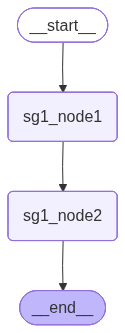

In [118]:
class Sg1State(TypedDict):
    sg1_data: str
    shared_data: str
    next_sg: str

def sg1_node1(state):
    print(f"this is sg1 data: {state.get("sg1_data")}")
    return state

def sg1_node2(state):
    choice = random.choice(["sg2", "sg3"])
    print(f"want to go to {choice}")
    return {
            "sg1_data": "new sg1 data",
            "shared_data": "new sg1 shared data",
            "next_sg": choice
        }

sg1_builder = StateGraph(Sg1State)
sg1_builder.add_node("sg1_node1", sg1_node1)
sg1_builder.add_node("sg1_node2", sg1_node2)

sg1_builder.add_edge(START, "sg1_node1")
sg1_builder.add_edge("sg1_node1", "sg1_node2")
sg1_builder.add_edge("sg1_node2", END)
memory_sg1 = InMemorySaver()
sg1 = sg1_builder.compile(checkpointer=memory_sg1)
display(Image(sg1.get_graph().draw_mermaid_png()))

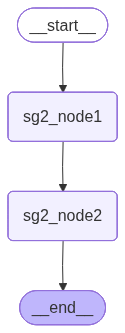

In [119]:
class Sg2State(TypedDict):
    sg2_data: str
    shared_data: str
    next_sg: str

def sg2_node1(state):
    print(f"this is sg2 data: {state.get("sg2_data")}")
    return state

def sg2_node2(state):
    choice = random.choice(["sg1", "sg3"])
    print(f"want to go to {choice}")
    return {
            "sg2_data": "new sg2 data",
            "shared_data": "new sg2 shared data",
            "next_sg": choice
        }

sg2_builder = StateGraph(Sg2State)
sg2_builder.add_node("sg2_node1", sg2_node1)
sg2_builder.add_node("sg2_node2", sg2_node2)

sg2_builder.add_edge(START, "sg2_node1")
sg2_builder.add_edge("sg2_node1", "sg2_node2")
sg2_builder.add_edge("sg2_node2", END)
sg2 = sg2_builder.compile()
display(Image(sg2.get_graph().draw_mermaid_png()))

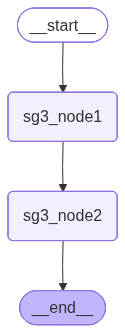

In [120]:
class Sg3State(TypedDict):
    sg3_data: str
    shared_data: str
    next_sg: str

def sg3_node1(state):
    print(f"this is sg3 data: {state.get("sg3_data")}")
    return state

def sg3_node2(state):
    choice = random.choice(["sg1", "sg2", END])
    print(f"want to go to {choice}")
    return {
            "sg3_data": "new sg3 data",
            "shared_data": "new sg3 shared data",
            "next_sg": choice
        }

sg3_builder = StateGraph(Sg3State)
sg3_builder.add_node("sg3_node1", sg3_node1)
sg3_builder.add_node("sg3_node2", sg3_node2)

sg3_builder.add_edge(START, "sg3_node1")
sg3_builder.add_edge("sg3_node1", "sg3_node2")
sg3_builder.add_edge("sg3_node2", END)
sg3 = sg3_builder.compile()
display(Image(sg3.get_graph().draw_mermaid_png()))

In [121]:
def router_sg1(state) -> Literal["sg2", "sg3"]:
    return state["next_sg"]

def router_sg2(state) -> Literal["sg1", "sg3"]:
    return state["next_sg"]

def router_sg3(state) -> Literal["sg2", "sg1", END]:
    return state["next_sg"]

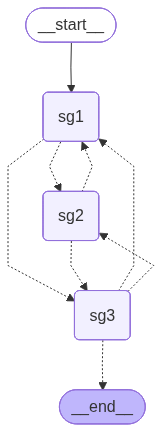

In [108]:
class ParentState(TypedDict):
    shared_data: str
    next_sg: str

builder = StateGraph(ParentState)
builder.add_node("sg1", sg1)
builder.add_node("sg2", sg2)
builder.add_node("sg3", sg3)

builder.add_edge(START, "sg1")
builder.add_conditional_edges("sg1", router_sg1)
builder.add_conditional_edges("sg2", router_sg2)
builder.add_conditional_edges("sg3", router_sg3)

from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

parent = builder.compile(checkpointer=memory)
display(Image(parent.get_graph().draw_mermaid_png()))

In [109]:
parent.invoke({"shared_data": "initial shared data"}, {"configurable": {"thread_id": "1"}})

this is sg1 data: None
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: None
want to go to sg3
this is sg3 data: None
want to go to sg1
this is sg1 data: None
want to go to sg3
this is sg3 data: None
want to go to sg1
this is sg1 data: None
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: None
want to go to sg2
this is sg2 data: None
want to go to sg1
this is sg1 data: None
want to go to sg3
this is sg3 data: None
want to go to __end__


{'shared_data': 'new sg3 shared data', 'next_sg': '__end__'}

only stuff common to both subgraph and parent graph remains saved

In [122]:
parent.get_state({"configurable": {"thread_id": "1"}}, subgraphs=True)

StateSnapshot(values={'shared_data': 'new sg3 shared data', 'next_sg': '__end__'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f09fdb1-323b-6c66-800c-40affc593a3b'}}, metadata={'source': 'loop', 'step': 12, 'parents': {}}, created_at='2025-10-02T21:59:31.624853+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f09fdb1-3231-6e92-800b-58c970884fbb'}}, tasks=(), interrupts=())